In [1]:
import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [2]:
from google.colab import files
uploaded = files.upload()

Saving VD_HCC.xlsx to VD_HCC.xlsx


Kích thước dữ liệu: (880, 22)
Các cột dữ liệu: ['record_id', 'Age', 'Gender', 'Platelets', 'INR', 'AST', 'ALT', 'Total_Bil', 'Dir_Bil', 'Albumin', 'Ure', 'Creatinine', 'Glucose', 'HBsAg', 'HCVAb', 'CEA', 'AFP', 'CA19-9', 'AST/ALT', 'APRI', 'FIB-4', 'label']


,record_id,Age,Gender,Platelets,INR,AST,ALT,Total_Bil,Dir_Bil,Albumin,...,Glucose,HBsAg,HCVAb,CEA,AFP,CA19-9,AST/ALT,APRI,FIB-4,label
0,20202,58,0.0,295.0,0.98,12.72,6.66,8.8,2.1,42.1,...,7.33,0.0,0.0,1.69,3.38,9.95,1.91,0.1078,0.9691,0
1,20203,76,0.0,249.0,1.14,97.71,59.04,32.0,13.2,30.4,...,6.37,0.0,0.0,NaN,44.78,25.08,1.65,0.9810,3.8813,1
2,20204,61,1.0,288.7,1.20,38.56,78.48,9.8,3.3,35.9,...,5.35,1.0,0.0,NaN,4.11,4.34,0.49,0.3339,0.9197,1
3,20205,71,0.0,116.1,1.03,94.98,77.23,12.6,3.3,31.3,...,3.98,1.0,0.0,2.48,13.49,72.28,1.23,2.0452,6.6094,1
4,20206,38,1.0,342.0,0.97,42.49,48.83,13.2,1.6,43.5,...,5.21,0.0,0.0,1.39,3.65,4.67,0.87,0.3106,0.6756,0


Creating feature correlation graph...


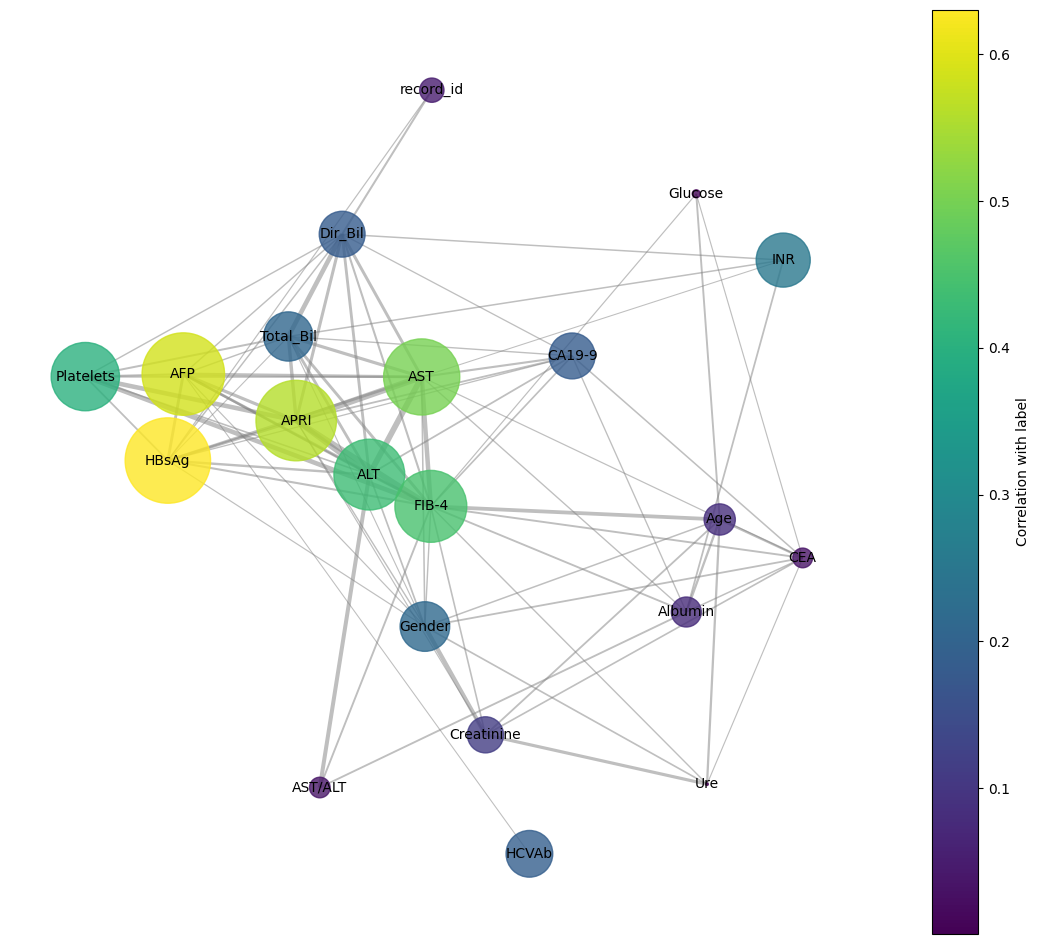

Calculating feature importance...
Top 10 most important features:


,feature,correlation_with_target,degree_centrality,betweenness_centrality,degree,importance_score
20,FIB-4,0.446800,0.85,0.240146,17,0.505764
13,HBsAg,0.630284,0.55,0.054160,11,0.433362
16,AFP,0.587537,0.50,0.101504,10,0.415466
5,AST,0.501085,0.65,0.060514,13,0.413588
19,APRI,0.559950,0.55,0.025038,11,0.396491
6,ALT,0.433330,0.55,0.031704,11,0.347843
3,Platelets,0.403315,0.40,0.000000,8,0.281326
2,Gender,0.212550,0.55,0.058851,11,0.267675
8,Dir_Bil,0.181755,0.55,0.062715,11,0.256516
7,Total_Bil,0.209577,0.55,0.023538,11,0.255892


Creating feature value graph...


/tmp/ipykernel_4744/3726205717.py:207: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  target_cmap = plt.cm.get_cmap('tab10', len(target_values))


KeyError: 'feature'

<Figure size 3000x2000 with 0 Axes>

In [4]:
import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Đọc dữ liệu
data_path = "VD_HCC.xlsx"  # đảm bảo file ở cùng thư mục notebook
# Use the correct encoding found in previous successful cells
df = pd.read_excel(data_path)

# df = pd.read_csv(data_path, encoding='ISO-8859-1')

print("Kích thước dữ liệu:", df.shape)
print("Các cột dữ liệu:", df.columns.tolist())
display(df.head())

def compute_feature_correlation(df, method='spearman'):
    if method == 'pearson':
        return df.corr(method='pearson')
    elif method == 'spearman':
        return df.corr(method='spearman')
    elif method == 'kendall':
        return df.corr(method='kendall')
    else:
        raise ValueError(f"Unknown correlation method: {method}")

def create_feature_graph(df, threshold=0.1, target_col='label'):
    """
    Create a graph where nodes are features and edges represent correlations

    Args:
        df: Input dataframe (should contain only numerical columns)
        threshold: Minimum absolute correlation threshold for creating an edge
        target_col: Target column name

    Returns:
        NetworkX graph
    """
    # Ensure target_col is in the DataFrame before computing correlation
    if target_col not in df.columns:
        print(f"Warning: Target column '{target_col}' not found in DataFrame. Skipping feature graph creation.")
        return nx.Graph() # Return an empty graph if target column is missing

    corr_matrix = compute_feature_correlation(df)

    G = nx.Graph()

    for feature in df.columns:
        if feature != target_col:
            # Check if feature exists in the correlation matrix index
            if feature in corr_matrix.index and target_col in corr_matrix.columns:
                 target_corr = abs(corr_matrix.loc[feature, target_col])
                 G.add_node(feature, correlation=target_corr)
            else:
                 print(f"Warning: Feature '{feature}' or target column '{target_col}' not found in correlation matrix. Skipping node creation for this feature.")


    for i, feature1 in enumerate(df.columns):
        if feature1 == target_col or feature1 not in G.nodes:
            continue
        for j, feature2 in enumerate(df.columns[i+1:], i+1):
            if feature2 == target_col or feature2 not in G.nodes:
                continue

            # Check if both features exist in the correlation matrix
            if feature1 in corr_matrix.index and feature2 in corr_matrix.columns:
                correlation = abs(corr_matrix.loc[feature1, feature2])
                if correlation >= threshold:
                    G.add_edge(feature1, feature2, weight=correlation)
            else:
                 print(f"Warning: Feature pair ('{feature1}', '{feature2}') not found in correlation matrix. Skipping edge creation.")


    return G


def visualize_feature_graph(G, target_col='label'):
    """
    Visualize the feature correlation graph

    Args:
        G: NetworkX graph
        target_col: Target column name
    """
    if not G or not G.nodes:
        print("Warning: Graph is empty. Cannot visualize.")
        return

    plt.figure(figsize=(14, 12))

    pos = nx.spring_layout(G, seed=42, k=1)

    # Ensure node has 'correlation' attribute before accessing it
    node_colors = [G.nodes[n].get('correlation', 0) for n in G.nodes]
    node_sizes = [6000 * G.nodes[n].get('correlation', 0.1) for n in G.nodes]
    edge_widths = [5 * G[u][v]['weight'] for u, v in G.edges]

    cmap = plt.cm.viridis

    nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                                  node_color=node_colors, cmap=cmap, alpha=0.8)

    edges = nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5,
                                  edge_color='gray')

    labels = nx.draw_networkx_labels(G, pos, font_size=10)

    # Check if node_colors is empty before creating ScalarMappable
    if node_colors:
        norm = Normalize(vmin=min(node_colors), vmax=max(node_colors))
        sm = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm,ax=plt.gca())
        cbar.set_label(f'Correlation with {target_col}')
    else:
        print("Warning: No node colors to create colorbar.")


    plt.title('', fontsize=16)
    plt.axis('off')
    plt.show()


def create_feature_value_graph(discretized_df, target_col='label'):
    """
    Create a graph where nodes are feature values (categories) and edges represent co-occurrence

    Args:
        discretized_df: Discretized dataframe with categorical features
        target_col: Target column name
    """
    if target_col not in discretized_df.columns:
        print(f"Warning: Target column '{target_col}' not found in DataFrame. Skipping feature value graph creation.")
        return nx.Graph()

    G = nx.Graph()

    target_values = discretized_df[target_col].unique()

    for col in discretized_df.columns:
        if col == target_col:
            continue

        for value in discretized_df[col].unique():
            if pd.isna(value):
                continue

            # Convert value to string for consistent node naming
            node_value_str = str(value)

            target_dist = {}
            for target_value in target_values:
                count = discretized_df[(discretized_df[col] == value) &
                                      (discretized_df[target_col] == target_value)].shape[0]
                total = discretized_df[discretized_df[col] == value].shape[0]
                target_dist[target_value] = count / total if total > 0 else 0

            # Handle case where target_dist might be empty if target_values is empty
            if target_dist:
                 most_common_target = max(target_dist.items(), key=lambda x: x[1])[0]
            else:
                 most_common_target = None


            node_name = f"{col}={node_value_str}"
            G.add_node(node_name,
                      feature=col,
                      value=value,
                      most_common_target=most_common_target,
                      target_distribution=target_dist)

    for idx, row in discretized_df.iterrows():
        sample_nodes = []
        for col in discretized_df.columns:
            if col == target_col:
                continue
            if pd.notna(row[col]):
                # Convert row[col] to string for consistent node naming
                node_value_str = str(row[col])
                node_name = f"{col}={node_value_str}"
                sample_nodes.append(node_name)

        for i, node1 in enumerate(sample_nodes):
            for node2 in sample_nodes[i+1:]:
                if G.has_edge(node1, node2):
                    G[node1][node2]['weight'] += 1
                else:
                    G.add_edge(node1, node2, weight=1)

    max_weight = max([G[u][v]['weight'] for u, v in G.edges]) if G.edges else 1
    for u, v in G.edges:
        G[u][v]['weight'] = G[u][v]['weight'] / max_weight

    if not G or not G.nodes:
        print("Warning: Feature value graph is empty. Cannot visualize.")
        return G

    plt.figure(figsize=(30, 20))

    pos = nx.spring_layout(G, seed=430, k=1)

    # Ensure target_values is not empty before creating target_cmap
    if target_values.size > 0:
        target_cmap = plt.cm.get_cmap('tab10', len(target_values))
        target_colors = {val: target_cmap(i) for i, val in enumerate(target_values)}
        node_colors = [target_colors.get(G.nodes[n].get('most_common_target'), 'gray') for n in G.nodes] # Use .get with default for safety
    else:
        node_colors = 'gray' # Default color if no target values


    node_sizes = [100 + 50 * G.degree[n] for n in G.nodes]


    edge_widths = [G[u][v]['weight'] * 5 for u, v in G.edges]

    feature_groups = {}
    for node in G.nodes:
        feature = G.nodes[node]['feature']
        if feature not in feature_groups:
            feature_groups[feature] = []
        feature_groups[feature].append(node)

    for i, (feature, nodes) in enumerate(feature_groups.items()):
        # Ensure nodes exist in the graph before drawing
        nodes_in_graph = [n for n in nodes if n in G.nodes]
        if nodes_in_graph:
            nx.draw_networkx_nodes(G, pos, nodelist=nodes_in_graph,
                                  node_size=[node_sizes[list(G.nodes).index(n)] for n in nodes_in_graph],
                                  node_color=[node_colors[list(G.nodes).index(n)] for n in nodes_in_graph],
                                  alpha=1)


    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3, edge_color='gray')

    important_nodes = [n for n in G.nodes if G.degree[n] > 2]  # Nodes with more connections
    nx.draw_networkx_labels(G, pos, {n: n for n in important_nodes}, font_size=8)

    # Ensure legend_elements is not empty before creating legend
    if target_values.size > 0:
        legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                     label=f'Target={val}',
                                     markerfacecolor=color, markersize=10)
                          for val, color in target_colors.items()]
        plt.legend(handles=legend_elements, loc='upper right')
    else:
        print("Warning: No target values to create legend.")


    plt.title('Feature Value Relationship Graph', fontsize=16)
    plt.axis('off')
    plt.show()

    return G


def extract_feature_importance(G, target_col='label'):
    """
    Calculate feature importance based on graph centrality

    Args:
        G: NetworkX graph
        target_col: Target column name

    Returns:
        DataFrame with feature importance
    """
    if not G or not G.nodes:
        print("Warning: Graph is empty. Cannot extract feature importance.")
        return pd.DataFrame()

    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G)

    importance = []
    for node in G.nodes:
        importance.append({
            'feature': node,
            'correlation_with_target': G.nodes[node].get('correlation', 0),
            'degree_centrality': degree_centrality.get(node, 0), # Use .get with default for safety
            'betweenness_centrality': betweenness_centrality.get(node, 0), # Use .get with default for safety
            'degree': G.degree[node]
        })

    importance_df = pd.DataFrame(importance)

    importance_df['importance_score'] = (
        importance_df['correlation_with_target'] * 0.4 +
        importance_df['degree_centrality'] * 0.3 +
        importance_df['betweenness_centrality'] * 0.3
    )

    importance_df = importance_df.sort_values('importance_score', ascending=False)

    return importance_df

# --- Pipeline chính ---
# Select only numerical columns for correlation graph
numerical_df = df.select_dtypes(include=np.number).copy()
# Ensure 'label' column exists and is numerical if it's the target
if 'label' in df.columns:
    if 'label' not in numerical_df.columns:
        # If label is not numerical, convert it if possible or handle appropriately
        try:
            numerical_df['label'] = pd.to_numeric(df['label'])
        except ValueError:
            print("Warning: 'label' column is not numerical and cannot be converted. Excluding from correlation graph.")
            # Exclude 'label' from numerical_df if it cannot be converted
            if 'label' in numerical_df.columns:
                numerical_df = numerical_df.drop(columns=['label'])
    # Ensure 'label' is the last column if it's included
    if 'label' in numerical_df.columns:
        label_col = numerical_df.pop('label')
        numerical_df['label'] = label_col


print("Creating feature correlation graph...")
# Pass the correct target column 'label' and the numerical dataframe
G = create_feature_graph(numerical_df, threshold=0.15, target_col='label')
visualize_feature_graph(G, target_col='label')

print("Calculating feature importance...")
# Pass the correct target column 'label'
importance_df = extract_feature_importance(G, target_col='label')
if not importance_df.empty:
    print("Top 10 most important features:")
    display(importance_df.head(10))
else:
    print("No feature importance data to display.")


print("Creating feature value graph...")
# Feature value graph (dùng tất cả cột đã rời rạc hóa)
# Assuming the original df is already 'discretized' in terms of having categorical values
discretized_df = df.copy() # Use the original df which has categorical values
# Pass the correct target column 'label'
value_graph = create_feature_value_graph(discretized_df, target_col='label')

print("Done!")